# Galaktička nastanjivost i procena broja terestrijalnih planeta u analozima Mlečnog puta

## Uvod

U ovom projektu analiziramo populaciju **analoga Mlečnog puta** iz kosmološke simulacije [IllustrisTNG (TNG100)](https://www.tng-project.org/) na crvenom pomaku $z = 0$.

Cilj je:
1. Identifikovati galaksije čije su zvezdana masa i stopa formiranja zvezda (SFR) slične Mlečnom putu.
2. Ispitati hemijsku ravnotežu između zvezdane i gasne metaličnosti.
3. Primeniti **proxy za broj terestrijalnih planeta** po Dayal et al. (2015) i uporediti dve populacije (one u hemijskoj ravnoteži i one van nje).
4. Proceniti potencijal za formiranje novih planeta u narednih 4.5 milijardi godina.

### Fizička motivacija

Galaktička nastanjivost zavisi od tri ključna parametra:
- $M_\ast$ — zvezdana masa (broj potencijalnih domaćina planeta)
- $Z_{\rm G}$ — gasna metaličnost (efikasnost formiranja terestrijalnih planeta)
- SFR — stopa formiranja zvezda (frekvencija sterilizujućih događaja tj. supernove)

Proxy koji koristimo (Dayal et al. 2015):
$$\frac{N_p}{N_{p,\rm MW}} = \left(\frac{M_\ast}{M_{\ast,\rm MW}}\right)^2 \left(\frac{Z_{\rm G}}{Z_{\rm MW}}\right)^\alpha \frac{\rm SFR_{\rm MW}}{\rm SFR}$$

gde je $\alpha = 1$ (linearni režim za terestrijalne planete).

### Reference
- Dayal, P. et al. (2015), ApJ, 810, L2  
- Mitrašinović et al. (2026), A&A (u štampi) — *The habitability trade-off: chemical decoupling and quenching in massive galaxies*  
- Licquia & Newman (2015), ApJ, 806, 96  
- Vagnozzi et al. (2017), ApJ, 839, 55

In [139]:
"""potrebni paketi"""
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import illustris_python as il
from scipy.stats import skew, kurtosis
from scipy.stats import ks_2samp

### 1. Učitavanje podataka iz IllustrisTNG (TNG100)

Koristimo simulaciju TNG100 na snimku $z=0$ (snap=99). 

**Napomena za pokretanje:** Ako imate lokalni pristup TNG100 podacima, podesite `BASE_PATH` na odgovarajuću putanju. Alternativno, notebook može da radi sa unapred generisanim `mw_analogs.csv` fajlom koji se preuzima sa git-a uputstvo se nalazi u README.md.

Kosmološki parametar $h = 0.6774$ koristi se za konverziju TNG jedinica u fizičke ($M_\odot$).

In [140]:
BASE_PATH = "data/TNG100-1"
BROAD_CSV_PATH = "data/broad_sample.csv"
CSV_PATH = "data/mw_analogs.csv"
H = 0.6774

# postoje sirovi podaci radi se ekstrakcija i filtriranje
if os.path.exists(BASE_PATH):
    print("Sirovi podaci pronađeni.")

    polja = ['SubhaloMassType', 'SubhaloSFR', 'SubhaloGasMetallicity',
             'SubhaloStarMetallicity', 'SubhaloFlag']
    subhalos = il.groupcat.loadSubhalos(BASE_PATH, 99, fields=polja)

    # definisanje filtera za masu
    m_star = subhalos['SubhaloMassType'][:, 4] * 1e10 / H
    m_gas = subhalos['SubhaloMassType'][:, 0] * 1e10 / H

    maska = (m_star >= 10**10.4) & (m_star <= 10**11.0) & \
            (subhalos['SubhaloSFR'] > 0) & \
            (subhalos['SubhaloGasMetallicity'] > 0) & \
            (subhalos['SubhaloFlag'] == 1)

    mw_ids = np.where(maska)[0]

    # Pakovanje u DataFrame
    mw_analogs = pd.DataFrame({
        'SubhaloID': mw_ids,
        'StellarMass': m_star[mw_ids],
        'GasMass': m_gas[mw_ids],
        'SFR': subhalos['SubhaloSFR'][mw_ids],
        'GasMetallicity': subhalos['SubhaloGasMetallicity'][mw_ids],
        'StarMetallicity': subhalos['SubhaloStarMetallicity'][mw_ids]
    })

    # cuva za sledece pokretanje
    mw_analogs.to_csv(CSV_PATH, index=False)
    print(f"Uspesno generisan CSV sa {len(mw_analogs)} MW analoga.")

# nema sirovih podataka ima samo csv
elif os.path.exists(CSV_PATH):
    print(f"Sirovi podaci nisu tu. Ucitava se gotov uzorak iz: {CSV_PATH}")
    mw_analogs = pd.read_csv(CSV_PATH)
    print(f"Uspešno ucitano {len(mw_analogs)} MW analoga.")

# nema nijedne strukture
else:
    raise FileNotFoundError(f"Greska! Podaci nisu pronađeni ni na {BASE_PATH} ni na {CSV_PATH}!")

Sirovi podaci pronađeni.
Uspesno generisan CSV sa 1703 MW analoga.


### 2. Relacija masa–metaličnost (MZR) za celu TNG100 populaciju

Pre analize analoga MW, prikazujemo **relaciju masa–metaličnost** za celu zvezda-formirajuću populaciju iz TNG100 na $z=0$.

Crvene isprekidane linije označavaju opseg zvezdane mase koji smo odabrali za MW analoge ($10^{10.4}$–$10^{11.0}\,M_\odot$). Zlatni dijamant označava poziciju Mlečnog puta.

Sirovi podaci pronađeni.


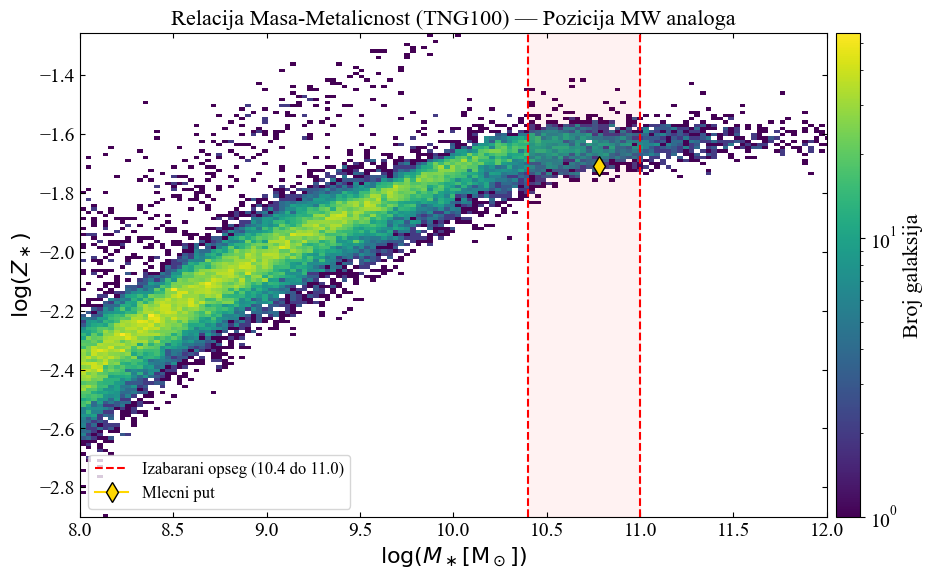

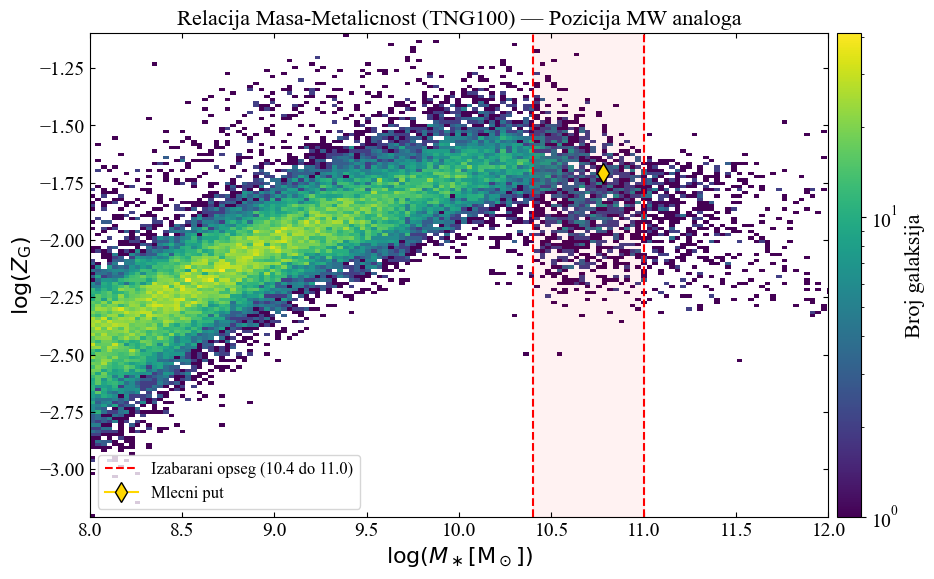

In [141]:
if os.path.exists(BASE_PATH):
    # Ovaj deo se izvršava SAMO kod tebe na računaru
    print("Sirovi podaci pronađeni.")

    fields = ['SubhaloFlag', 'SubhaloMassType', 'SubhaloSFR',
              'SubhaloStarMetallicity', 'SubhaloGasMetallicity']
    subs = il.groupcat.loadSubhalos(BASE_PATH, 99, fields=fields)

    temp_df = pd.DataFrame()
    temp_df['SubhaloFlag'] = subs['SubhaloFlag']

    with np.errstate(divide='ignore', invalid='ignore'):
        temp_df['log_Mstar'] = np.log10(subs['SubhaloMassType'][:, 4] * 1e10 / H)
        temp_df['SFR'] = subs['SubhaloSFR']
        temp_df['log_Zstar'] = np.log10(subs['SubhaloStarMetallicity'])
        temp_df['log_Zgas'] = np.log10(subs['SubhaloGasMetallicity'])

    mask_broad = (
        (temp_df['log_Mstar'] >= 8) &
        (temp_df['SFR'] > 0) &
        np.isfinite(temp_df['log_Zstar']) &
        np.isfinite(temp_df['log_Zgas']) &
        (temp_df['SubhaloFlag'] == 1)
    )

    df_broad = temp_df[mask_broad][['log_Mstar', 'log_Zstar', 'log_Zgas']]

elif os.path.exists(BROAD_CSV_PATH):
    # Ovaj deo se izvršava KOD PROFESORA na računaru i tokom pytest-a
    print(f"Ucitavam pre-procesirani siroki uzorak: {BROAD_CSV_PATH}")
    df_broad = pd.read_csv(BROAD_CSV_PATH)

else:
    raise FileNotFoundError(f"Greska! Podaci nisu pronađeni na {BASE_PATH} ni na {BROAD_CSV_PATH}!")

M_STAR_MW = 6.0e10 # zvezdana masa
SFR_MW = 3 # stopa formiranja zvezda
ZG_MW = 0.0196 # metalicnost gasa

plt.figure(figsize=(10, 6))
plt.hist2d(df_broad['log_Mstar'], df_broad['log_Zstar'], bins=150, cmap='viridis',
           cmin=1, norm=LogNorm(vmin=1))
plt.axvline(10.4, color='red', ls='--', label='Izabarani opseg (10.4 do 11.0)')
plt.axvline(11.0, color='red', ls='--')
plt.axvspan(10.4, 11.0, color='red', alpha=0.05)
plt.plot(np.log10(M_STAR_MW), np.log10(ZG_MW), marker='d', color='gold',
         markersize=10, markeredgecolor='black', label='Mlecni put')
plt.xlim(8, 12)
plt.xlabel(r'$\log(M_\ast  [\rm M_\odot])$')
plt.ylabel(r'$\log(Z_\ast)$')
plt.title('Relacija Masa-Metalicnost (TNG100) — Pozicija MW analoga')
plt.colorbar(label='Broj galaksija', pad=0.01)
plt.legend(loc='lower left', framealpha=0.8)
plt.tight_layout()
plt.tick_params(direction='in', top=True, right=True)

#plt.savefig('relacija_masa_metalicnost*.pdf')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist2d(df_broad['log_Mstar'], df_broad['log_Zgas'], bins=150, cmap='viridis',
           cmin=1, norm=LogNorm(vmin=1))
plt.axvline(10.4, color='red', ls='--', label='Izabarani opseg (10.4 do 11.0)')
plt.axvline(11.0, color='red', ls='--')
plt.axvspan(10.4, 11.0, color='red', alpha=0.05)
plt.plot(np.log10(M_STAR_MW), np.log10(ZG_MW), marker='d', color='gold',
         markersize=10, markeredgecolor='black', label='Mlecni put')
plt.xlim(8, 12)
plt.xlabel(r'$\log(M_\ast  [\rm M_\odot])$')
plt.ylabel(r'$\log(Z_{\rm G})$')
plt.title('Relacija Masa-Metalicnost (TNG100) — Pozicija MW analoga')
plt.colorbar(label='Broj galaksija', pad=0.01)
plt.legend(loc='lower left', framealpha=0.8)
plt.tight_layout()
plt.tick_params(direction='in', top=True, right=True)

#plt.savefig('relacija_masa_metalicnost_gas.pdf')
plt.show()

### 3. Opisna statistika populacije MW analoga

Posle selekcije, analiziramo statističke karakteristike uzorka.

Prikazujemo raspodele tri ključne veličine: zvezdane mase, SFR i gasne metaličnosti, i poredimo sa vrednostima Mlečnog puta.

Pored standardnih mera (srednja vrednost, standardna devijacija), koristimo i robusne mere (medijana, IQR) jer su raspodele asimetrične. Skewness i kurtosis opisuju oblik raspodele.

Statisticka analiza uzorka:

Stellar Mass (log M*):
  Srednja vr. (Mean): 10.646
  Medijana (Median): 10.626
  Stand. dev. (Std): 0.167
  Sigma_G (IQR): 0.272
  Skewness: 0.384
  Kurtosis: -0.946

Star Formation Rate (log SFR):
  Srednja vr. (Mean): -0.200
  Medijana (Median): 0.131
  Stand. dev. (Std): 0.981
  Sigma_G (IQR): 1.136
  Skewness: -1.268
  Kurtosis: 1.027

Gas Metallicity (log Z_gas):
  Srednja vr. (Mean): -1.781
  Medijana (Median): -1.760
  Stand. dev. (Std): 0.187
  Sigma_G (IQR): 0.257
  Skewness: -0.320
  Kurtosis: 0.012



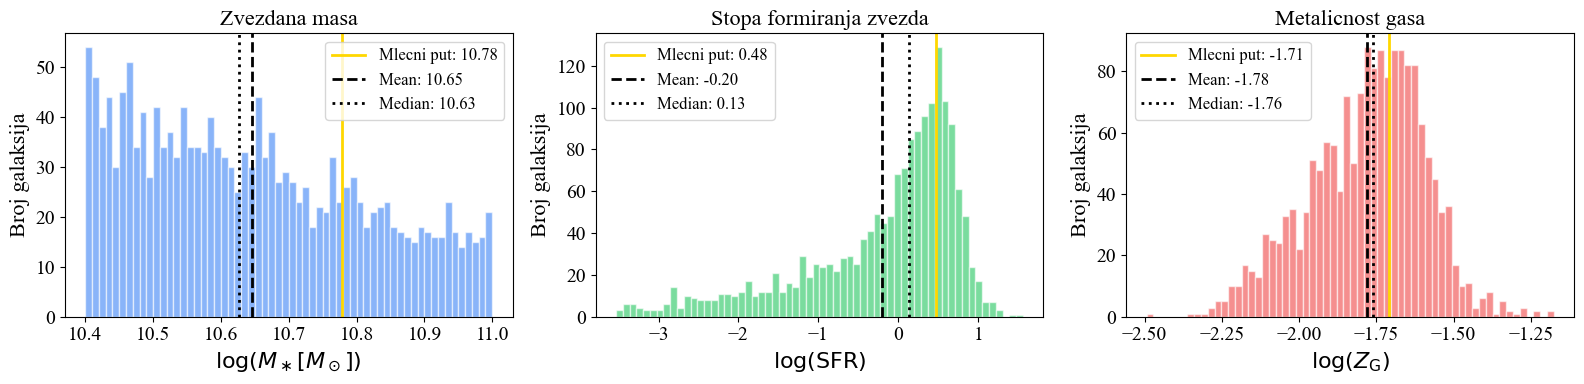

Medijana odnosa log(Z*/Zgas): 0.092
Srednja vrednost odnosa log(Z*/Zgas): 0.134


In [142]:
# ucitavanje podataka
df = pd.read_csv(CSV_PATH)

# prebacivanje u log10 bolje za grafike
df['log_Mstar'] = np.log10(df['StellarMass'])
df['log_SFR'] = np.log10(df['SFR'])
df['log_Zgas'] = np.log10(df['GasMetallicity'])
df['log_Zstar'] = np.log10(df['StarMetallicity'])

def statisticka_analiza(kolona, promenljiva):
    """funkcija za opisnu stat analizu uzorka"""
    analiza_podataka = df[kolona].replace([np.inf, -np.inf], np.nan) # replace inf with NaN
    analiza_podataka = df[kolona].dropna() # cistimo podatke od NaN vrednosti

    aritmeticka_sredina = np.mean(analiza_podataka)
    standardna_devijacija = np.std(analiza_podataka, ddof=1)

    # Robusne mere
    medijana = np.median(analiza_podataka)
    q75, q25 = np.percentile(analiza_podataka, [75, 25])
    sigma_g = q75 - q25 # IQR (interkvartilni opseg)

    # oblik raspodele
    sk = skew(analiza_podataka)
    kurt = kurtosis(analiza_podataka)

    print(f'\033[1m{promenljiva}\033[0m:')
    print(f'  Srednja vr. (Mean): {aritmeticka_sredina:.3f}')
    print(f'  Medijana (Median): {medijana:.3f}')
    print(f'  Stand. dev. (Std): {standardna_devijacija:.3f}')
    print(f'  Sigma_G (IQR): {sigma_g:.3f}')
    print(f'  Skewness: {sk:.3f}')
    print(f'  Kurtosis: {kurt:.3f}\n')

    return aritmeticka_sredina, medijana

print('Statisticka analiza uzorka:\n')
mean_m, med_m = statisticka_analiza('log_Mstar', 'Stellar Mass (log M*)')
mean_sfr, med_sfr = statisticka_analiza('log_SFR', 'Star Formation Rate (log SFR)')
mean_z, med_z = statisticka_analiza('log_Zgas', 'Gas Metallicity (log Z_gas)')


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
boje = ['#3B82F6', '#22C55E', '#EF4444']
kolone = ['log_Mstar', 'log_SFR', 'log_Zgas']
kolone_za_mw = [M_STAR_MW, SFR_MW, ZG_MW]
naslovi = [r'Zvezdana masa', r'Stopa formiranja zvezda', r'Metalicnost gasa']
x_ose = [r'$\log(M_\ast [M_\odot])$', r'$\log(\rm{SFR})$', r'$\log(Z_{\rm G})$']

for i in range(3):
    podaci = df[kolone[i]].dropna()
    mean_val = np.mean(podaci)
    med_val = np.median(podaci)

    axes[i].hist(podaci, bins=60, color=boje[i], alpha=0.6, edgecolor='white')
    axes[i].axvline(np.log10(kolone_za_mw[i]), color='gold', lw=2,
                    label=f'Mlecni put: {np.log10(kolone_za_mw[i]):.2f}')
    axes[i].axvline(mean_val, color='black', ls='--', lw=2, label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(med_val, color='black', ls=':', lw=2, label=f'Median: {med_val:.2f}')
    axes[i].set_title(naslovi[i])
    axes[i].set_xlabel(x_ose[i])
    axes[i].set_ylabel('Broj galaksija')
    axes[i].legend()

plt.tight_layout()
#plt.savefig('medijana_i_srv.pdf')
plt.show()


log_odnos = np.log10(df['StarMetallicity'] / df['GasMetallicity'])
vrednost_medijana = log_odnos.median()
print(f"Medijana odnosa log(Z*/Zgas): {vrednost_medijana:.3f}")

vrednost_sredina = log_odnos.mean()
print(f"Srednja vrednost odnosa log(Z*/Zgas): {vrednost_sredina:.3f}")


### 4. Hemijska ravnoteža i klasifikacija populacije

Definišemo **prag hemijske ravnoteže** na osnovu odnosa zvezdane i gasne metaličnosti:

$$\log(Z_\ast / Z_{\rm G}) \leq 0.1 \quad \Rightarrow \quad \text{u ravnoteži (equilibrium)}$$
$$\log(Z_\ast / Z_{\rm G}) > 0.1 \quad \Rightarrow \quad \text{van ravnoteže (non-equilibrium)}$$

**Fizički smisao:** Galaksije van hemijske ravnoteže imaju metal-bogatu zvezdanu populaciju ali razređen gasni, sto je signal nedavnih spajanja ili akrecionih događaja koji su uneli metal-siromašan gas.

Klasifikacija populacije:
Broj galaksija u ravnotezi: 877 (51.50%)
Broj galaksija van ravnoteze: 826 (48.50%)


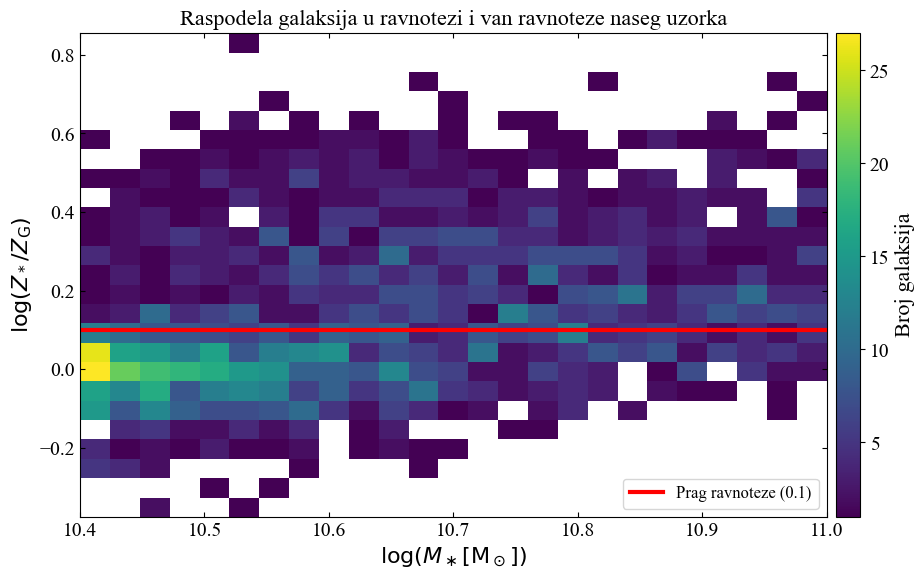

In [143]:
PRAG = 0.1

df.replace([np.inf, -np.inf], np.nan, inplace=True)
kljucne_kolone = ['StellarMass', 'GasMass', 'SFR', 'GasMetallicity', 'StarMetallicity']
df.dropna(subset=kljucne_kolone, inplace=True)

df['log_odnos'] = np.log10(df['StarMetallicity'] / df['GasMetallicity'])

# klasifikacija galaksija u one koje su u ravnotezi i one van nje
df['tip'] = np.where(df['log_odnos'] > PRAG, 'non-equilibrium', 'equilibrium')

ravnoteza = df['tip'] == 'equilibrium'
van_ravnoteze = df['tip'] == 'non-equilibrium'

n_ukupno = len(df)
n_ravnoteza = ravnoteza.sum()
n_van_ravnoteze = van_ravnoteze.sum()

print("Klasifikacija populacije:")
print(f"Broj galaksija u ravnotezi: {n_ravnoteza} ({100*n_ravnoteza/n_ukupno:.2f}%)")
print(f"Broj galaksija van ravnoteze: {n_van_ravnoteze} ({100*n_van_ravnoteze/n_ukupno:.2f}%)")


plt.figure(figsize=(10, 6))
plt.hist2d(df['log_Mstar'], df['log_odnos'], bins=25, cmap='viridis', cmin=1, vmin=1)
plt.axhline(PRAG, color='red', linestyle='-', linewidth=3, label='Prag ravnoteze (0.1)')
plt.xlim(10.4, 11)
plt.xlabel(r'$\log(M_\ast  [\rm M_\odot])$')
plt.ylabel(r'$\log(Z_*/Z_{\rm G})$')
plt.title('Raspodela galaksija u ravnotezi i van ravnoteze naseg uzorka')
plt.colorbar(label='Broj galaksija', pad=0.01)
plt.legend(loc='lower right', framealpha=0.8)
plt.tight_layout()
plt.tick_params(direction='in', top=True, right=True)

### 5. Raspodela odnosa zvezdane i gasne mase

Poredimo dve populacije u pogledu odnosa $M_\ast / M_{\rm G}$.

**Očekivanje:** Galaksije van ravnoteže treba da budu siromašnije gasom (veći $M_\ast/M_{\rm G}$), što je konzistentno sa delimičnim gašenjem i smanjenim potencijalom za dalju formaciju zvezda i planeta.

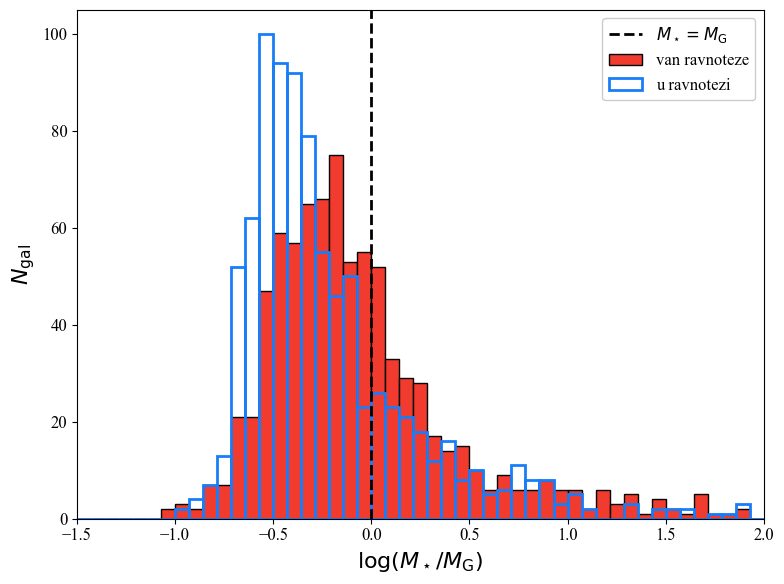

In [144]:
df['log_mass_odnos'] = np.log10(df['StellarMass'] / df['GasMass'])

log_odnos_eq = df[df['tip'] == 'equilibrium']['log_mass_odnos']
log_odnos_neq = df[df['tip'] == 'non-equilibrium']['log_mass_odnos']

# definisan broj binova
binovi = np.linspace(-1.5, 2.0, 50)


plt.figure(figsize=(8, 6))
plt.axvline(0, color='black', linestyle='--', linewidth=2, label=r'$M_\star = M_{\rm G}$')

# galaksije van ravnoteze
plt.hist(log_odnos_neq, bins=binovi, color="#f13b2e", edgecolor='black', label='van ravnoteze')

# galaksije u ravnotezi
plt.hist(log_odnos_eq, bins=binovi, fill=False, edgecolor="#187df9",
         linewidth=2, label='u ravnotezi')

plt.xlim(-1.5, 2)
plt.xlabel(r'$\log(M_\star/M_{\rm G})$')
plt.ylabel(r'$N_{\rm gal}$')
plt.tick_params(direction='out', top=False, right=False, labelsize=12)
plt.legend(loc='upper right', fontsize=12, framealpha=1.0)
plt.tight_layout()
plt.show()

### 6. Proxy za galaktičku nastanjivost (Dayal et al. 2015)

Primenjujemo proxy za broj terestrijalnih planeta:

$$\frac{N_p}{N_{p,\rm MW}} = \left(\frac{M_\ast}{M_{\ast,\rm MW}}\right)^2 \left(\frac{Z_{\rm G}}{Z_{\rm MW}}\right)^\alpha \frac{\rm SFR_{\rm MW}}{\rm SFR}$$

sa $\alpha = 1$ (linearni režim za terestrijalne planete).

Galaksije u ravnotezi N = 877
Medijana: 0.507
Srednja vrednost: 31.750
16. percentil: 0.204
84. percentil: 2.090
Maksimum: 9980.437

Galaksije van ravnoteze N = 826
Medijana: 4.813
Srednja vrednost: 169.247
16. percentil: 0.660
84. percentil: 116.735
Maksimum: 11142.956

KS test Np/Np,MW: D=0.491, p=1.342e-93


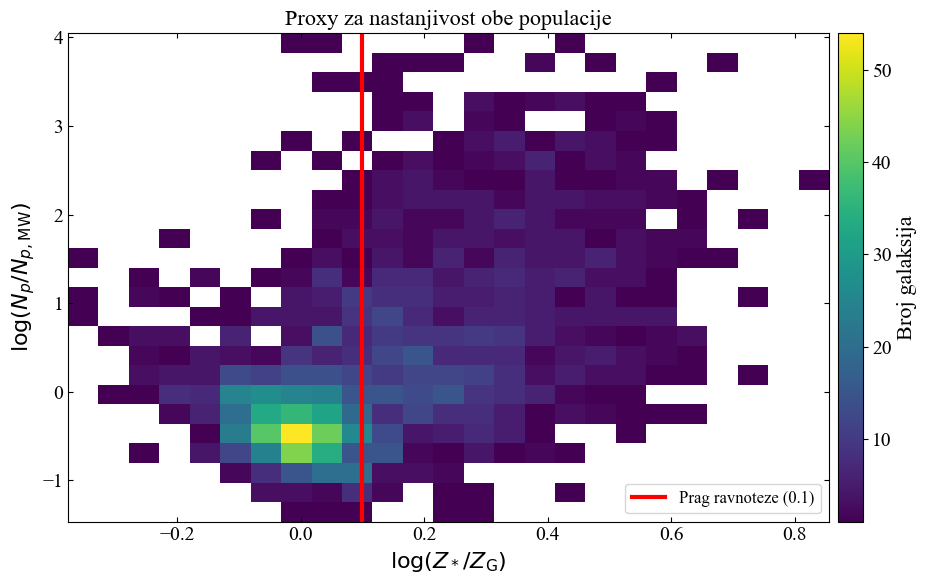

In [145]:
ALFA = 1.0 # eksponent metalicnosti

df['Np_rel'] = (
        (df['StellarMass']/M_STAR_MW)**2
        * (df['GasMetallicity']/ZG_MW)**ALFA
        * (SFR_MW/df['SFR'])
)


# opisna statistika za obe populacije sa proxyjem
for naslov, tip in[('Galaksije u ravnotezi', ravnoteza),
                   ('Galaksije van ravnoteze', van_ravnoteze)]:
    podaci = df.loc[tip, 'Np_rel']
    print(f"\033[1m{naslov} N = {tip.sum()}\033[0m")
    print(f"Medijana: {podaci.median():.3f}")
    print(f"Srednja vrednost: {podaci.mean():.3f}")
    print(f"16. percentil: {podaci.quantile(0.16):.3f}")
    print(f"84. percentil: {podaci.quantile(0.84):.3f}")
    print(f"Maksimum: {podaci.max():.3f}\n")

# KS test pokusava da obori sledecu hipotezu
# Raspodela vrednosti Np_rel za galaksije u ravnoteži i galaksije van ravnoteze je potpuno ista."
ks_D, ks_p = ks_2samp(df.loc[ravnoteza, 'Np_rel'].dropna(),
                      df.loc[van_ravnoteze, 'Np_rel'].dropna())
print(f"KS test Np/Np,MW: D={ks_D:.3f}, p={ks_p:.3e}")


plt.figure(figsize=(10, 6))
plt.hist2d(df['log_odnos'], np.log10(df['Np_rel']), bins=25, cmap='viridis', cmin=1, vmin=1)
plt.axvline(PRAG, color='red', linestyle='-', linewidth=3, label='Prag ravnoteze (0.1)')
plt.xlabel(r'$\log(Z_*/Z_{\rm G})$')
plt.ylabel(r'$\log(N_p/N_{p,\rm MW})$')
plt.title('Proxy za nastanjivost obe populacije')
plt.colorbar(label='Broj galaksija', pad=0.01)
plt.legend(loc='lower right', framealpha=0.8)
plt.tight_layout()
plt.tick_params(direction='in', top=True, right=True)
plt.tight_layout()
plt.show()

### 7. Procena prirasta nastanjivosti tokom narednih 4.5 milijardi godina

Procenjujemo **budući potencijal za formiranje planeta** tako što računamo očekivani priraštaj proxy vrednosti ($\Delta N_p$) tokom 4.5 Gyr, uz konzervativnu pretpostavku da SFR i $Z_{\rm G}$ ostaju konstantni.

$$\Delta N_p \propto \frac{[(M_\ast + \Delta M_\ast)^2 - M_\ast^2]}{M_{\ast,\rm MW}^2} \cdot \left(\frac{Z_{\rm G}}{Z_{\rm MW}}\right)^\alpha \cdot \frac{\rm SFR_{\rm MW}}{\rm SFR}$$

gde je $\Delta M_\ast = \rm SFR \times \Delta t$.

**Ključni rezultat:** Galaksije *van* ravnoteže imaju **manji** $\Delta N_p$ pri istoj masi, formiće manje novih planeta u budućnosti jer im je SFR potisnut a gasna metaličnost razređena.

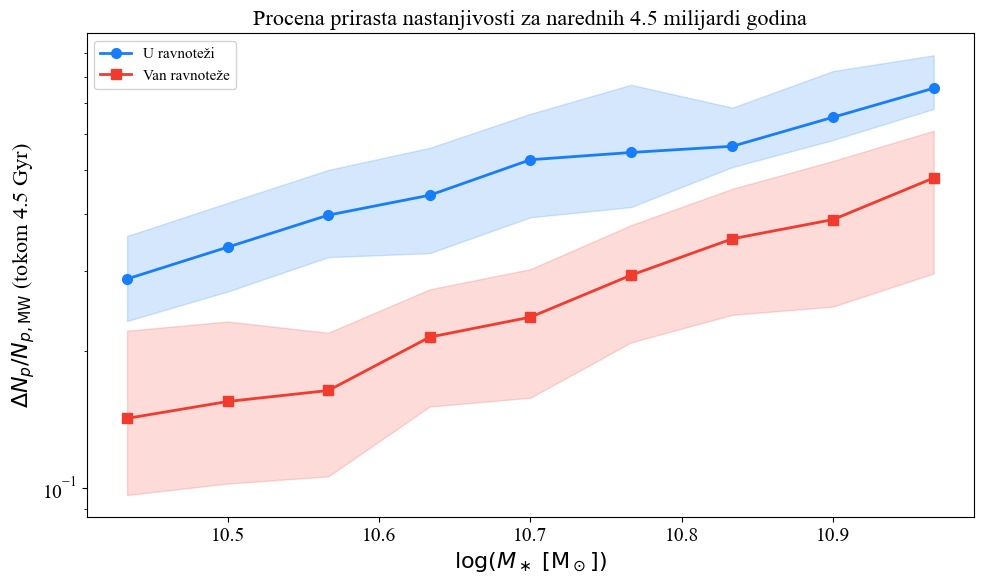

In [146]:
BUDUCNOST = 4.5e9 # vremenski interval za buducu procenu formiranja planeta

delta_M = df['SFR'] * BUDUCNOST  # = delta M*

df['Delta_Np'] = (
    ((df['StellarMass'] + delta_M)**2 - df['StellarMass']**2)
    / M_STAR_MW**2
    * (df['GasMetallicity'] / ZG_MW)**ALFA
    * (SFR_MW / df['SFR'])
)

# Pravimo binove za masu (od 10.4 do 11.0, sto je tvoj raspon za MW analoge)
bins_masa = np.linspace(10.4, 11.0, 10, endpoint=True)  # 9 binova širine
MIN_GAL_BIN = 5  # Minimalan broj galaksija u binu da bi crtali tačku

fig, ax = plt.subplots(figsize=(10, 6))

# Pakujemo tvoje maske i boje koje si koristio u histogramu
grupe = [
    ('U ravnoteži', ravnoteza, "#187df9", 'o'),       # Plava
    ('Van ravnoteže', van_ravnoteze, "#f13b2e", 's')  # Crvena
]

for naziv, maska, boja, marker in grupe:
    # Izdvajamo samo galaksije iz te grupe
    pod_pop = df[maska].copy()

    # Razvrstavamo ih u binove po masi
    pod_pop['bin'] = pd.cut(pod_pop['log_Mstar'], bins=bins_masa)

    # Računamo medijanu i percentile za svaki bin odjednom
    stats = pod_pop.groupby('bin', observed=False)['Delta_Np'].agg(
        N='count',
        med='median',
        p16=lambda x: x.quantile(0.16),
        p84=lambda x: x.quantile(0.84)
    )

    # Odbacujemo binove koji nemaju dovoljno galaksija
    stats = stats[stats['N'] >= MIN_GAL_BIN]

    # Uzimamo centre binova za X osu
    centri = [b.mid for b in stats.index]

    # Crtanje linije (medijana) i senke (16-84 percentil)
    ax.plot(centri, stats['med'], color=boja, marker=marker, lw=2, ms=7, label=naziv)
    ax.fill_between(centri, stats['p16'], stats['p84'], color=boja, alpha=0.18)

ax.set_yscale('log')
ax.set_xlabel(r'$\log(M_\ast\;[\rm M_\odot])$')
ax.set_ylabel(r'$\Delta N_p/N_{p,\mathrm{MW}}$ (tokom 4.5 Gyr)')
ax.set_title('Procena prirasta nastanjivosti za narednih 4.5 milijardi godina')
ax.legend(fontsize=11, framealpha=0.85)
plt.tight_layout()
plt.show()
